In [ ]:
#### Statistical Tests and Analyses
import math
import numpy as np
from scipy.stats import shapiro, ttest_rel, levene, wilcoxon, mannwhitneyu, ranksums
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import json

INST_FILE = Path("../../data/transformed/inst_final.csv")
POP_FILE = Path("../../data/transformed/pop_final.csv")
TT_FILE = Path("../../data/transformed/tt_final_country.csv")
FB_FILE = Path("../../data/transformed/fb_final.csv")

FILE_NAMES = {INST_FILE: "Instagram", POP_FILE: "Population", TT_FILE: "TikTok", FB_FILE: "Facebook"}
FILES = [INST_FILE, TT_FILE, FB_FILE, POP_FILE]

fb = pd.read_csv(FB_FILE,sep=";")
tt = pd.read_csv(TT_FILE,sep=";")
pop = pd.read_csv(POP_FILE,sep=";")
inst = pd.read_csv(INST_FILE,sep=";")

In [ ]:
### Descriptives on Available Locations

LOCATIONS_PATH = Path("../../data/raw/")
INST_FILE_CLEAN = Path("../../data/cleaned/inst_cleaned.csv")
POP_FILE_CLEAN = Path("../../data/cleaned/pop_cleaned/.csv")
FB_FILE_CLEAN = Path("../../data/cleaned/fb_cleaned.csv")
TT_FILE_PATH = Path("../../data/cleaned/")
TT_LEVEL = ["country","province","city","dma"]

##### locations with data extracted

TT_FILES_CLEAN = [TT_FILE_PATH / f"tt_cleaned_{level}.csv" for level in TT_LEVEL]

FILES_CLEAN = [INST_FILE_CLEAN] + TT_FILES_CLEAN + [FB_FILE_CLEAN, POP_FILE_CLEAN]


for file in FILES_CLEAN:
    df = pd.read_csv(file,sep=";")

    countries = df["country_code"].dropna().unique()

    print(f"Extracted {file.name}: {len(df)} entries | Countries: {sorted(countries)} \n")

###### original location list

for level in TT_LEVEL:
    LOCATIONS_FILE = LOCATIONS_PATH / f"input_{level}.json" 

    with open(LOCATIONS_FILE, "r", encoding="utf-8") as f:
        data = json.load(f)

    unique_country_codes = set(entry["country_code"] for entry in data["inputs"] if entry.get("country_code"))

    country_codes_list = list(unique_country_codes)

    print(f"Original {LOCATIONS_FILE.name}: {len(data)} entries | Countries: {sorted(countries)} \n")

In [ ]:
### Descriptives on Country Level Ratios
AGE_GROUPS = ['13_17', '18_24', '25_34', '35_44', '45_54', '55_100']

def count_gender_ratios(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    for group in AGE_GROUPS:
        ratio_col = f"age_{group}_ratio_std"
        if ratio_col in df.columns:
            below = (df[ratio_col] < 1).sum()
            above = (df[ratio_col] > 1).sum()
            equal = (df[ratio_col] == 1).sum()
            max_val = df[ratio_col].max()
            min_val = df[ratio_col].min()
            max_name = df.loc[df[ratio_col].idxmax(), "name"] if not df[ratio_col].isna().all() else "N/A"
            min_name = df.loc[df[ratio_col].idxmin(), "name"] if not df[ratio_col].isna().all() else "N/A"

            print(f"\n Standardized Ratio for Age {group}:")
            print(f"  < 1: {below}, > 1: {above}, = 1: {equal}")
            print(f"  Max: {max_val:.2f} ({max_name})")
            print(f"  Min: {min_val:.2f} ({min_name})")
    
    if "total_ratio_std" in df.columns:
        total_below = (df["total_ratio_std"] < 1).sum()
        total_above = (df["total_ratio_std"] > 1).sum()
        total_equal = (df["total_ratio_std"] == 1).sum()
        max_val = df["total_ratio_std"].max()
        min_val = df["total_ratio_std"].min()
        max_name = df.loc[df["total_ratio_std"].idxmax(), "name"] if not df["total_ratio_std"].isna().all() else "N/A"
        min_name = df.loc[df["total_ratio_std"].idxmin(), "name"] if not df["total_ratio_std"].isna().all() else "N/A"

        print(f"\n Standardized Ratio Total:")
        print(f"  < 1: {total_below}, > 1: {total_above}, = 1: {total_equal}")
        print(f"  Max: {max_val:.2f} ({max_name})")
        print(f"  Min: {min_val:.2f} ({min_name})")

# Run analysis for each file
for file_path, name in FILE_NAMES.items():
    df = pd.read_csv(file_path, sep=";")
    count_gender_ratios(df, name)

# Analysis specific on TikTok Data. Values < 1000 indicate that dimension too small and data not reliable.
    if name == "TikTok":
        print(f"\n=== TikTok Estimate Check (<1000 users) ===")
        for group in AGE_GROUPS:
            for gender in ["women", "men"]:
                col = f"age_{group}_{gender}"
                if col in df.columns:
                    below_1k = (df[col] < 1000).sum()
                    print(f"{col}: {below_1k} regions below 1,000")


C:\Users\Hanna\AppData\Local\Temp\ipykernel_34656\3494726645.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(tt_std["iso3"],rotation=90)
C:\Users\Hanna\AppData\Local\Temp\ipykernel_34656\3494726645.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(inst_std["iso3"],rotation=90)
C:\Users\Hanna\AppData\Local\Temp\ipykernel_34656\3494726645.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(fb_std["iso3"],rotation=90)


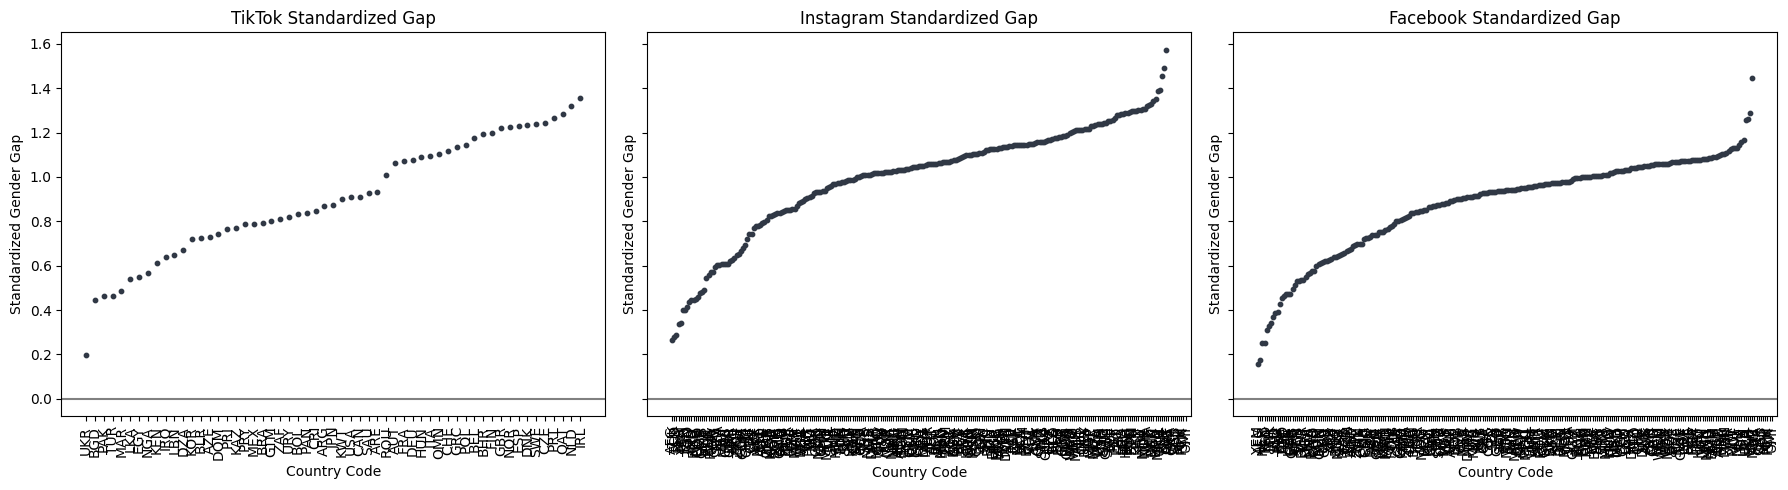

In [42]:
### Create Scatterplot of Tiktok Relative Gender Gap
tt_std = tt[["iso3","total_ratio_std"]].sort_values("total_ratio_std", ascending=True)
inst_std = inst[["iso3","total_ratio_std"]].sort_values("total_ratio_std", ascending=True)
fb_std = fb[["iso3","total_ratio_std"]].sort_values("total_ratio_std", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(tt_std["iso3"], tt_std["total_ratio_std"],color='#303845', s=10)
axes[0].axhline(0, color='gray')
axes[0].set_title("TikTok Standardized Gap")
axes[0].set_xticklabels(tt_std["iso3"],rotation=90)
axes[0].set_xlabel("Country Code")
axes[0].set_ylabel("Standardized Gender Gap")
axes[0].grid(False)

axes[1].scatter(inst_std["iso3"], inst_std["total_ratio_std"],color='#303845', s=10)
axes[1].axhline(0, color='gray')
axes[1].set_title("Instagram Standardized Gap")
axes[1].set_xticklabels(inst_std["iso3"],rotation=90)
axes[1].set_xlabel("Country Code")
axes[1].set_ylabel("Standardized Gender Gap")
axes[1].grid(False)

axes[2].scatter(fb_std["iso3"], fb_std["total_ratio_std"],color='#303845', s=10)
axes[2].axhline(0, color='gray')
axes[2].set_title("Facebook Standardized Gap")
axes[2].set_xticklabels(fb_std["iso3"],rotation=90)
axes[2].set_xlabel("Country Code")
axes[2].set_ylabel("Standardized Gender Gap")
axes[2].grid(False)

plt.tight_layout()
plt.show()

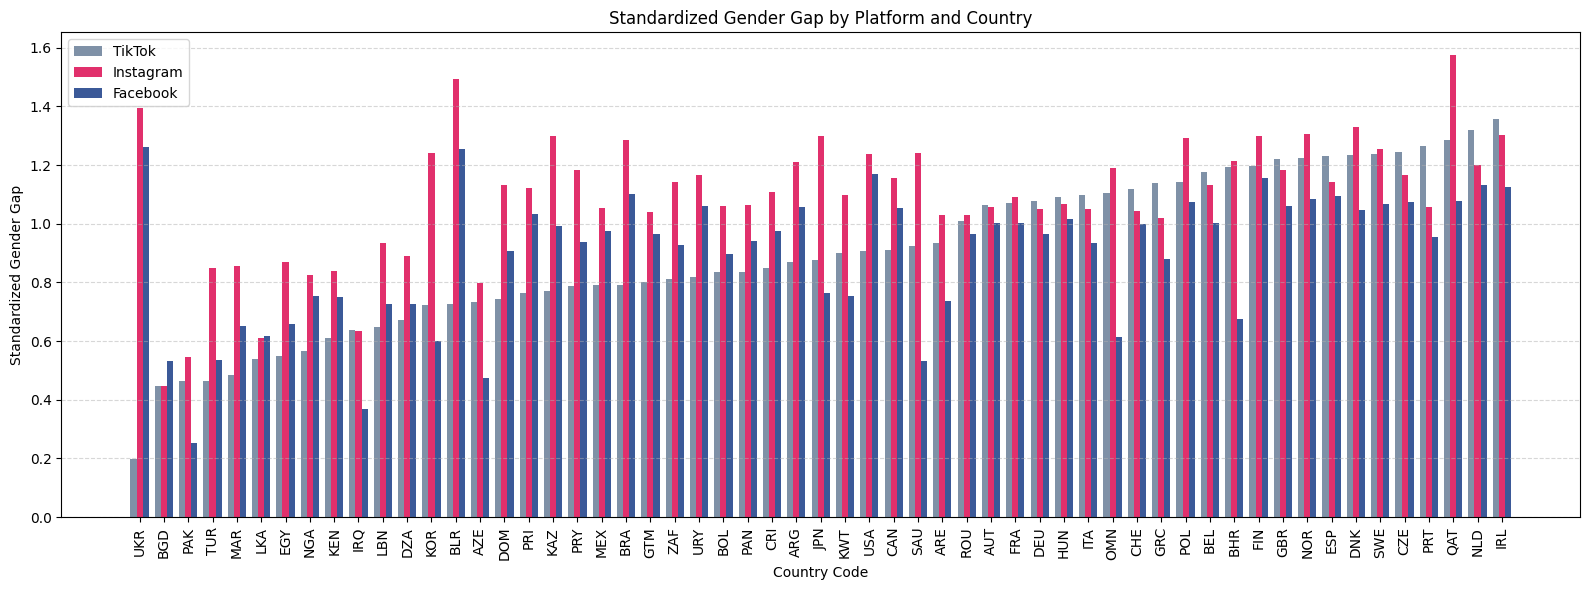

In [53]:
# Compare sources side by side
merged = tt[["iso3", "total_ratio_std"]].merge(inst[["iso3", "total_ratio_std"]], on="iso3", suffixes=("_tt", "_inst")).merge(fb[["iso3", "total_ratio_std"]], on="iso3").rename(columns={"total_ratio_std": "total_ratio_std_fb"})

# Sort by TikTok for visual clarity
merged = merged.sort_values("total_ratio_std_tt", ascending=True)

# Plot
x = merged["iso3"]
x_pos = range(len(x))

plt.figure(figsize=(16, 6))
bar_width = 0.25

plt.bar([i - bar_width for i in x_pos], merged["total_ratio_std_tt"], width=bar_width, label='TikTok', color='#7F91A7')
plt.bar(x_pos, merged["total_ratio_std_inst"], width=bar_width, label='Instagram', color='#E1306C')
plt.bar([i + bar_width for i in x_pos], merged["total_ratio_std_fb"], width=bar_width, label='Facebook', color='#3b5998')

plt.xticks(x_pos, x, rotation=90)
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel("Country Code")
plt.ylabel("Standardized Gender Gap")
plt.title("Standardized Gender Gap by Platform and Country")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

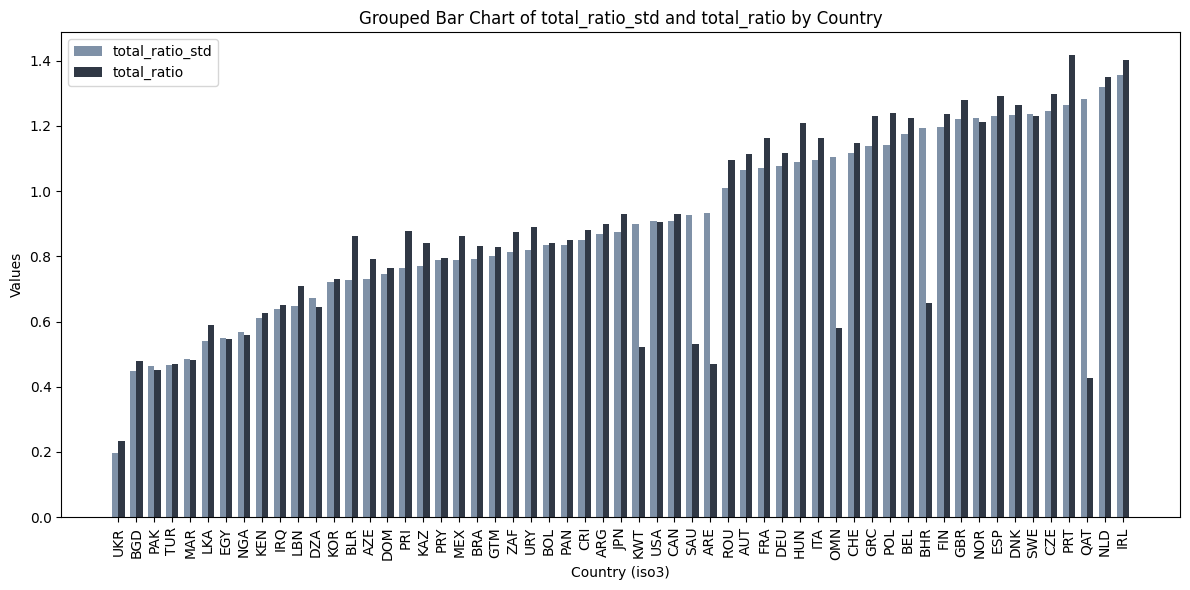

In [54]:
# compare TikTok gap vs standardized gap
merged = tt[["iso3", "total_ratio_std", "total_ratio"]].sort_values("total_ratio_std", ascending=True)

countries = merged["iso3"]
std_values = merged["total_ratio_std"]
raw_values = merged["total_ratio"]

x = np.arange(len(countries))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(12,6))
bars1 = ax.bar(x - width/2, std_values, width, label='total_ratio_std', color= '#7F91A7')
bars2 = ax.bar(x + width/2, raw_values, width, label='total_ratio', color='#303845')

# Add labels, title, and legend
ax.set_xlabel('Country (iso3)')
ax.set_ylabel('Values')
ax.set_title('Grouped Bar Chart of total_ratio_std and total_ratio by Country')
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

In [45]:
# TikTok descriptive table summary
ratio_columns = [col for col in tt.columns if col.endswith("_ratio_std")]
summary = tt[ratio_columns].agg(["min", "max", "mean", "std"]).transpose()

summary.columns = ["Min", "Max", "Mean", "Std Dev"]
summary.rename(index={
    'age_13_17_ratio_std': '13–17',
    'age_18_24_ratio_std': '18–24',
    'age_25_34_ratio_std': '25–34',
    'age_35_44_ratio_std': '35–44',
    'age_45_54_ratio_std': '45–54',
    'age_55_100_ratio_std': '55+',
    'total_ratio_std':'total'
}, inplace=True)

print(summary)

            Min       Max      Mean   Std Dev
13–17  1.001691  1.116214  1.048081  0.018481
18–24  0.071582  1.511802  1.018617  0.342898
25–34  0.395624  1.423606  0.936498  0.290313
35–44  0.288937  1.521994  0.961121  0.327071
45–54  0.429497  2.011882  1.055390  0.350969
55+    0.301773  1.466522  0.879845  0.248191
total  0.196993  1.356238  0.903161  0.269331


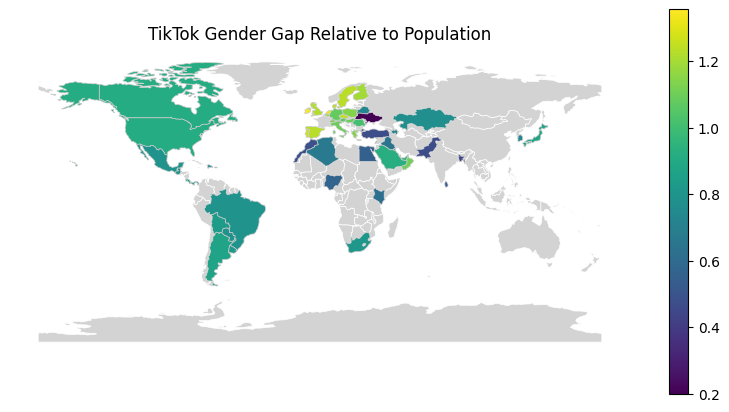

In [46]:
# creating map of tiktok 
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load world geometry
world = gpd.read_file("../../data/raw/map/ne_110m_admin_0_countries.shp")
tt_std1 = tt_std.rename(columns={"iso3":"ISO_A3"})

merged = world.merge(tt_std1, on='ISO_A3', how='left')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

merged.dropna(subset=["total_ratio_std"]).plot(
    column='total_ratio_std',
    cmap='viridis',
    linewidth=0.5,
    edgecolor='0.8',
    legend=True,
    ax=ax
)

ax.set_title('TikTok Gender Gap Relative to Population')
plt.axis('off')
plt.show()



In [48]:
print(tt.columns.to_list())

['iso2', 'age_13_17_women', 'age_13_17_men', 'age_18_24_women', 'age_18_24_men', 'age_25_34_women', 'age_25_34_men', 'age_35_44_women', 'age_35_44_men', 'age_45_54_women', 'age_45_54_men', 'age_55_100_women', 'age_55_100_men', 'age_13_17_ratio', 'age_18_24_ratio', 'age_25_34_ratio', 'age_35_44_ratio', 'age_45_54_ratio', 'age_55_100_ratio', 'total_men', 'total_women', 'total_all', 'total_ratio', 'iso3', 'age_13_17_ratio_std', 'age_18_24_ratio_std', 'age_25_34_ratio_std', 'age_35_44_ratio_std', 'age_45_54_ratio_std', 'age_55_100_ratio_std', 'total_ratio_std', 'age_13_17_women_pen', 'age_13_17_men_pen', 'age_18_24_women_pen', 'age_18_24_men_pen', 'age_25_34_women_pen', 'age_25_34_men_pen', 'age_35_44_women_pen', 'age_35_44_men_pen', 'age_45_54_women_pen', 'age_45_54_men_pen', 'age_55_100_women_pen', 'age_55_100_men_pen', 'total_men_pen', 'total_women_pen', 'total_all_pen']


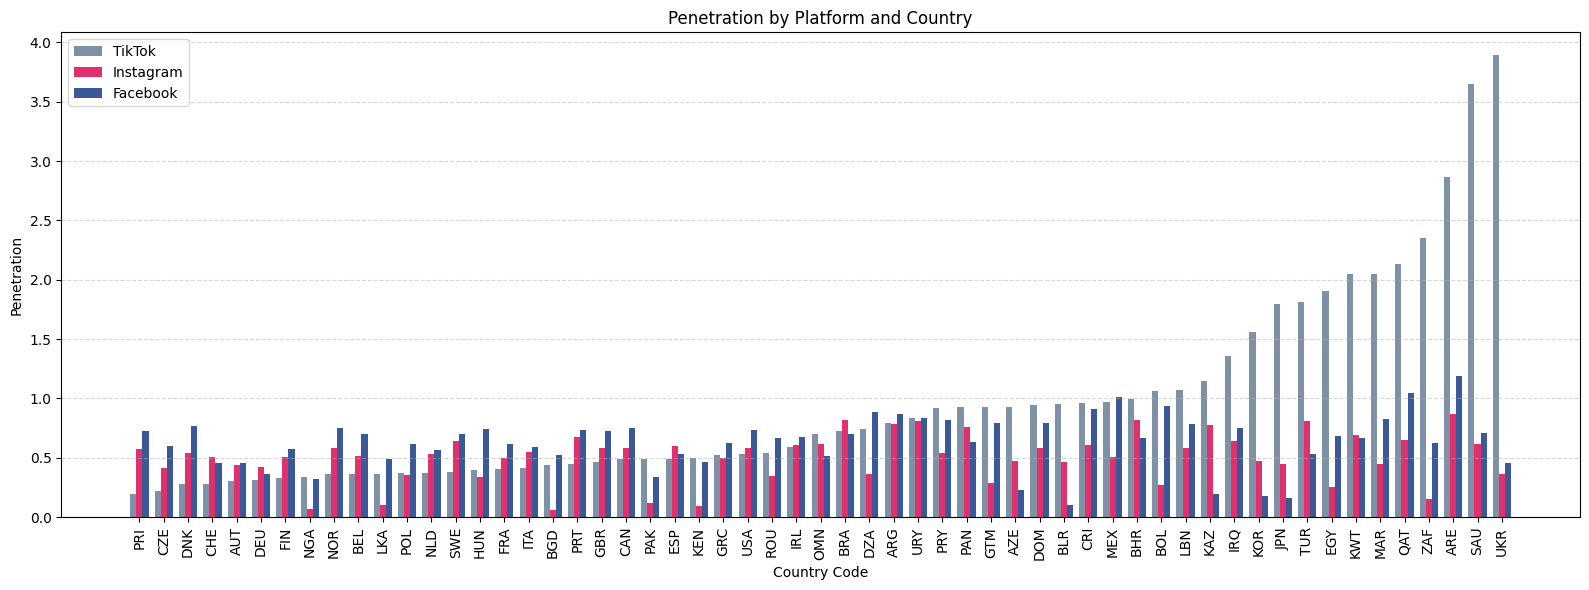

In [55]:
# Compare penetration side by side
merged = tt[["iso3", "total_all_pen"]].merge(inst[["iso3", "total_all_pen"]], on="iso3", suffixes=("_tt", "_inst")).merge(fb[["iso3", "total_all_pen"]], on="iso3").rename(columns={"total_all_pen": "total_penetration"})

# Sort by TikTok for visual clarity
merged = merged.sort_values("total_all_pen_tt", ascending=True)

# Plot
x = merged["iso3"]
x_pos = range(len(x))

plt.figure(figsize=(16, 6))
bar_width = 0.25

plt.bar([i - bar_width for i in x_pos], merged["total_all_pen_tt"], width=bar_width, label='TikTok', color= '#7F91A7')
plt.bar(x_pos, merged["total_all_pen_inst"], width=bar_width, label='Instagram', color='#E1306C')
plt.bar([i + bar_width for i in x_pos], merged["total_penetration"], width=bar_width, label='Facebook', color='#3b5998')

plt.xticks(x_pos, x, rotation=90)
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel("Country Code")
plt.ylabel("Penetration")
plt.title("Penetration by Platform and Country")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

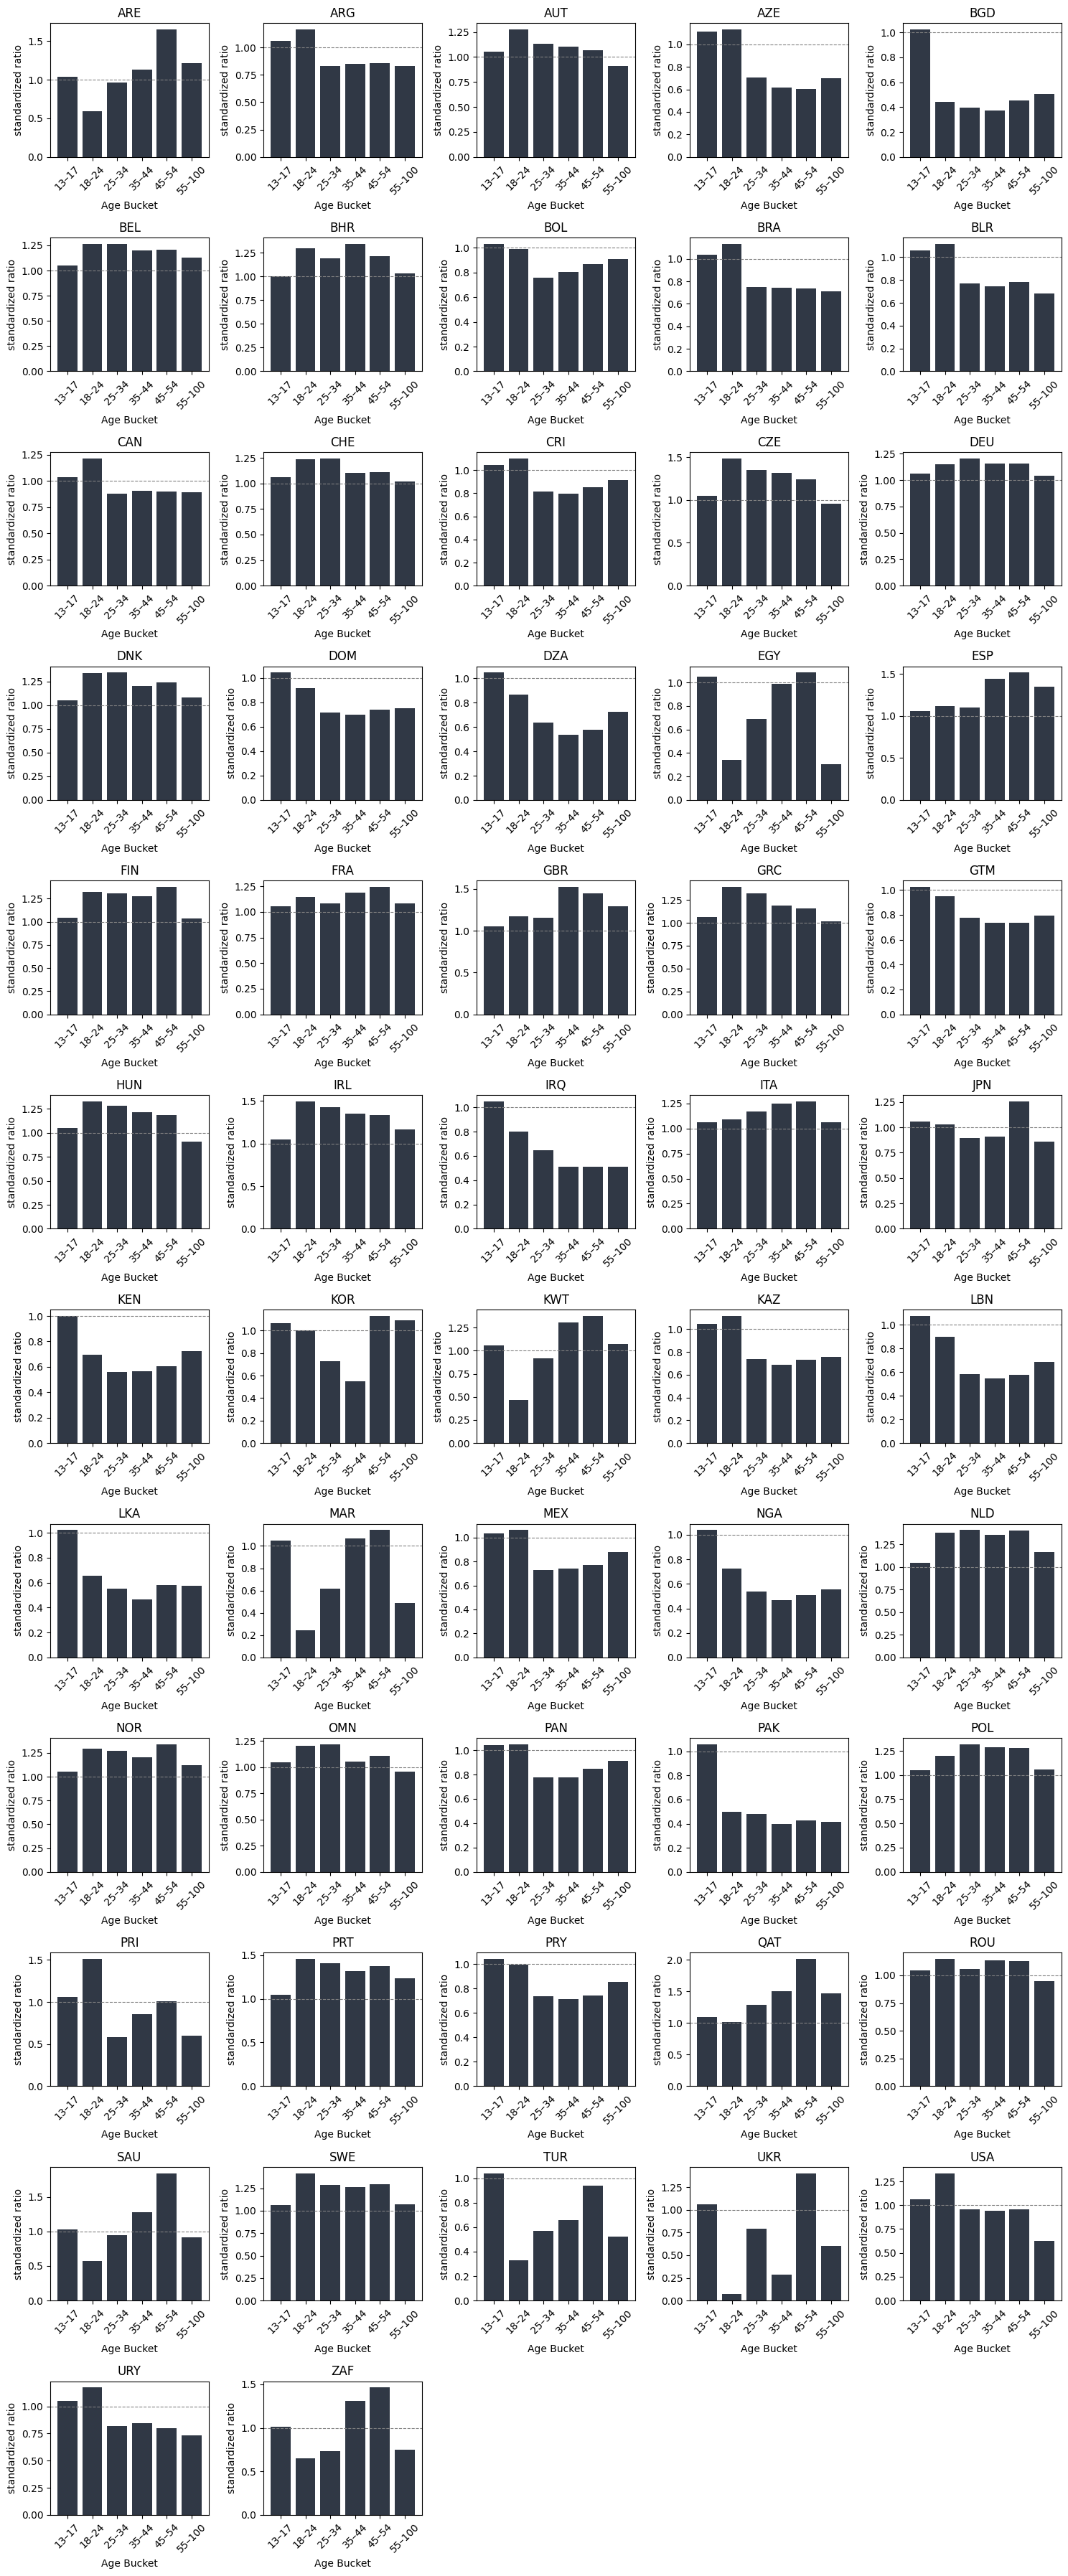

In [60]:
# bar charts per age and country

age_groups = ['13_17', '18_24', '25_34', '35_44', '45_54', '55_100']
ratio_cols = [f'age_{age}_ratio_std' for age in age_groups if f'age_{age}_ratio_std' in tt.columns]
age_labels = [age.replace('_', '–') for age in age_groups if f'age_{age}_ratio_std' in tt.columns]


# Get unique countries
countries = tt['iso3'].unique()

# Calculate grid dimensions
n_countries = len(countries)
cols = 5  # or adjust based on your preference
rows = int(np.ceil(n_countries / cols))

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten() if n_countries > 1 else [axes]

# Create bar chart for each country
for i, country in enumerate(countries):
    row = tt[tt['iso3'] == country].iloc[0]
    values = [row[col] for col in ratio_cols]
    
    axes[i].bar(age_labels, values, color='#303845')
    axes[i].set_title(f'{country}')
    axes[i].set_xlabel('Age Bucket')
    axes[i].set_ylabel('standardized ratio')
    axes[i].axhline(1, linestyle='--', color='gray', linewidth=0.8)  # gender parity line
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for i in range(n_countries, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

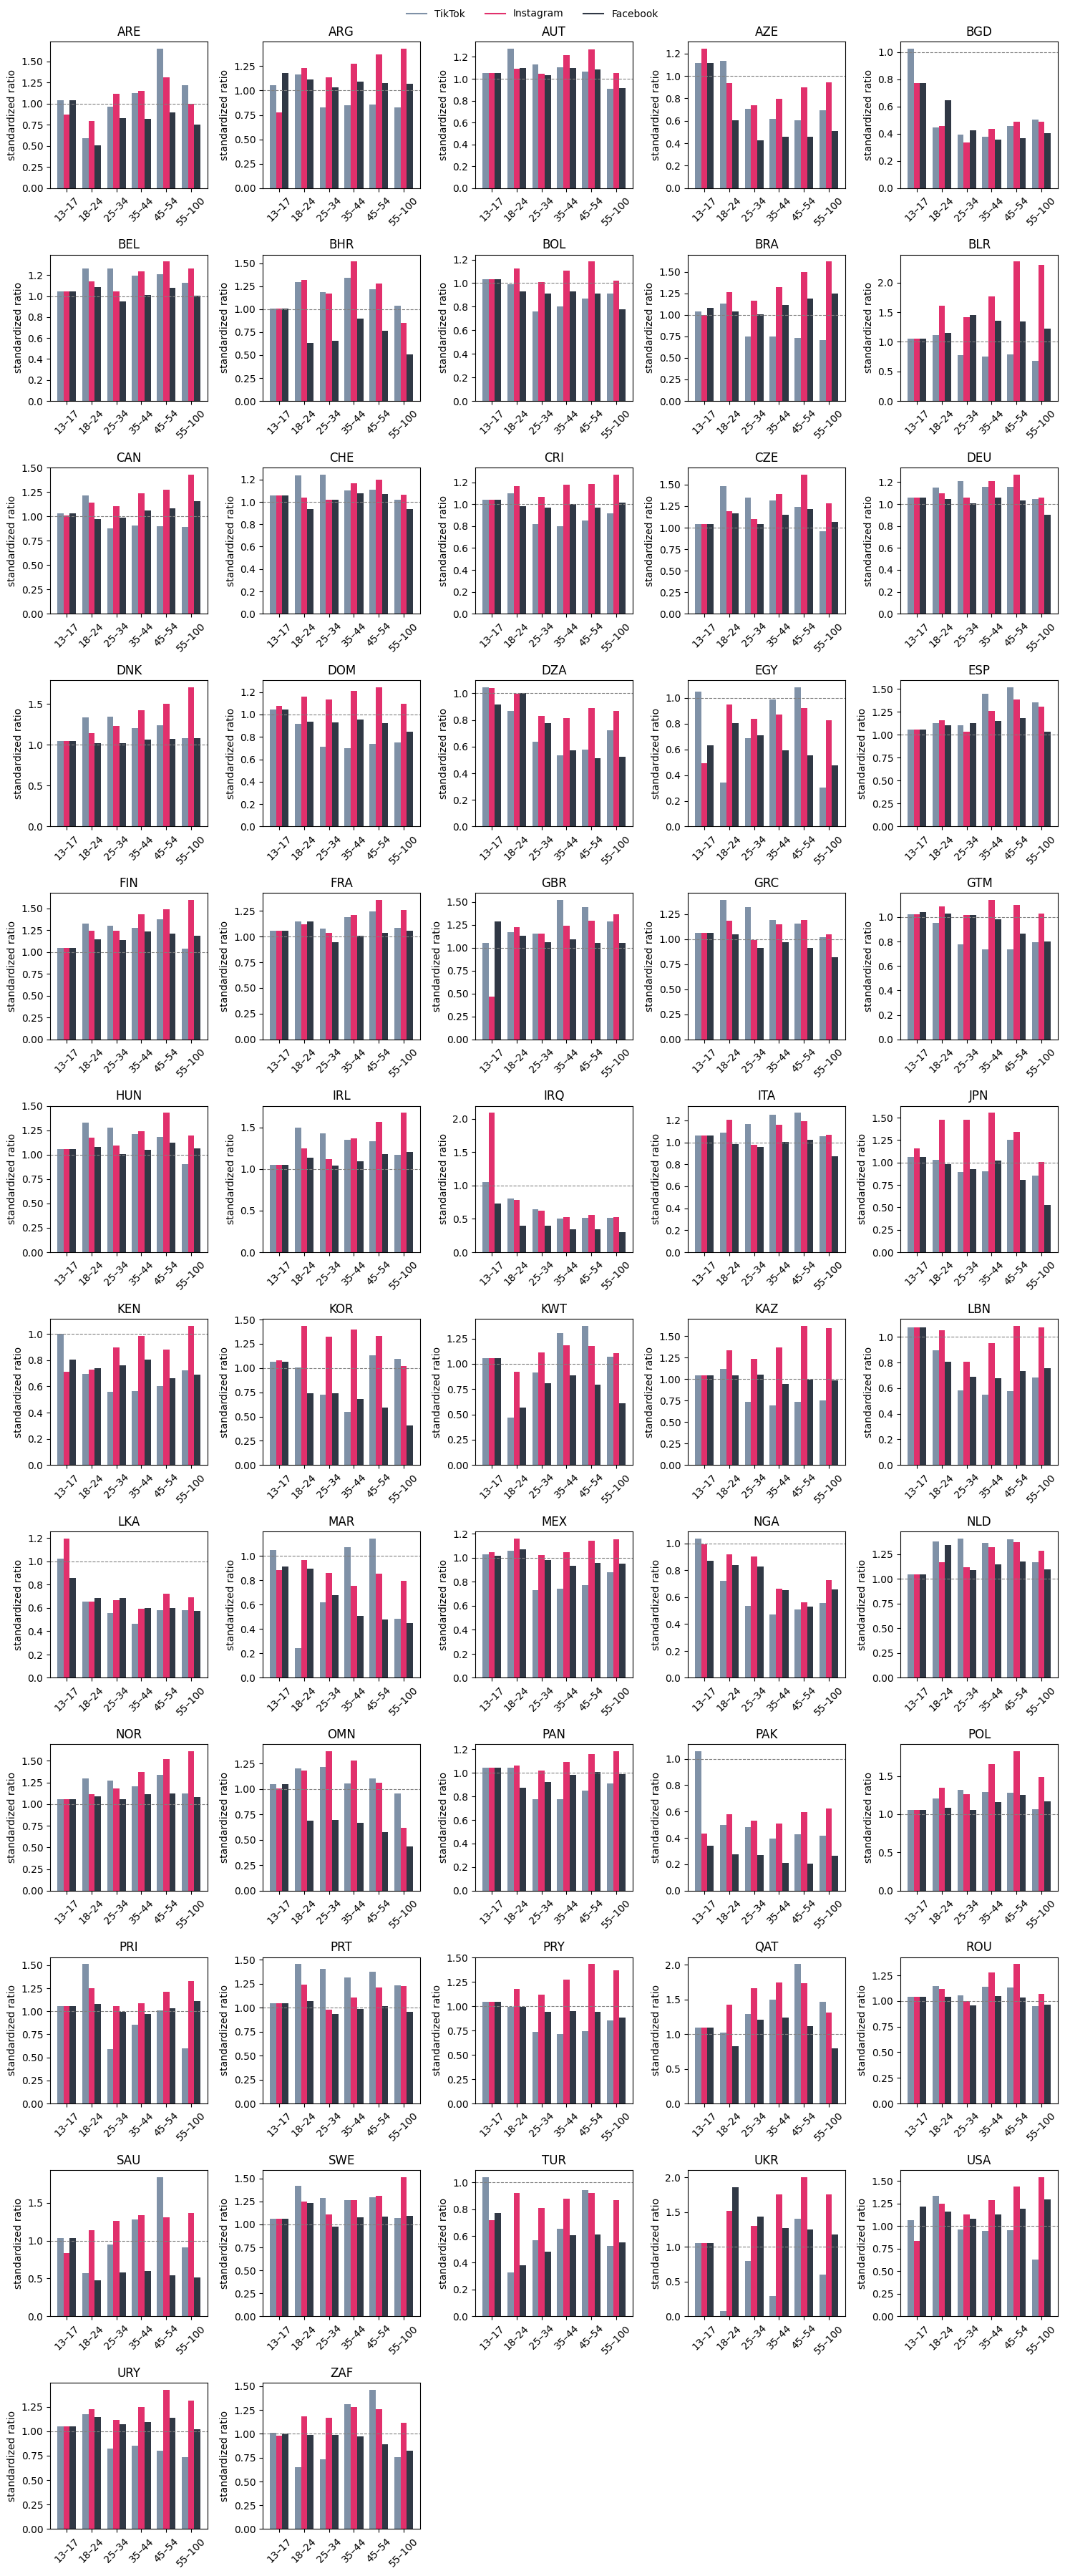

In [74]:
# bar charts per age and country by platform

age_groups = ['13_17', '18_24', '25_34', '35_44', '45_54', '55_100']
ratio_cols = [f'age_{age}_ratio_std' for age in age_groups if f'age_{age}_ratio_std' in tt.columns]
age_labels = [age.replace('_', '–') for age in age_groups if f'age_{age}_ratio_std' in tt.columns]


# Get unique countries
countries = tt['iso3'].unique()

# Calculate grid dimensions
n_countries = len(countries)
cols = 5  # or adjust based on your preference
rows = int(np.ceil(n_countries / cols))

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten() if n_countries > 1 else [axes]

bar_width = 0.25
x = np.arange(len(age_labels))  # one position per age group

# Create bar chart for each country
for i, country in enumerate(countries):
    row_tt = tt[tt['iso3'] == country].iloc[0]
    row_fb = fb[fb['iso3'] == country].iloc[0]
    row_inst = inst[inst['iso3'] == country].iloc[0]
    values_tt = [row_tt[col] for col in ratio_cols]
    values_fb = [row_fb[col] for col in ratio_cols]
    values_inst = [row_inst[col] for col in ratio_cols]
    
    axes[i].bar(x - bar_width, values_tt, width=bar_width, label='TT', color='#7F91A7')
    axes[i].bar(x, values_inst, width=bar_width, label='INST', color='#E1306C')
    axes[i].bar(x + bar_width, values_fb, width=bar_width, label='FB', color='#303845')

    axes[i].set_title(f'{country}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(age_labels, rotation=45)
    axes[i].set_ylabel('standardized ratio')
    axes[i].axhline(1, linestyle='--', color='gray', linewidth=0.8)  # gender parity line

# Hide empty subplots
for i in range(n_countries, len(axes)):
    axes[i].axis('off')

platforms = [
    plt.Line2D([], [], color='#7F91A7', label='TikTok'),
    plt.Line2D([], [], color='#E1306C', label='Instagram'),
    plt.Line2D([], [], color='#303845', label='Facebook')
]
fig.legend(handles=platforms, loc='upper center', ncol=3, frameon=False, fontsize='medium')

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()